[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_08/MFM_ch8_sem_conformal/MFM_ch8_sem_conformal.ipynb)

# Modelling Financial Markets — Seminar 8: Backtesting and Evaluating Risk Forecasts

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza — Bucharest University of Economic Studies.*

- **Part A**: numerical check of the ten derivations.
- **Part B**: backtesting and inference on the S&P 500, BET, Bitcoin and EUR/RON.
- **Part C**: open questions and AI critique (C1: a provisional model for a Romanian trading portfolio; C2: critique of an AI answer; C3: ES backtests in R).
- The seminar comes before Lecture 8; the slides open with a short primer (Kupiec, Christoffersen, durations and DQ, traffic light, $Z_2$, scores and Diebold–Mariano).
- **In class**: A1, A3, A5, A7, B1, B5, C2. **After the lecture**: B2, B3 and B7; the other sections are optional extensions.
- **[Solved]** problems are fully worked out (code and output); **[Proposed]** problems have an empty cell for you: their solutions are discussed in the seminar.
- Worked examples to follow: A1 for A2; A3 for A4; A6 for A9; A7 for A10; A5 and B1 for B2; B3 for B4; B5 for B6; B7 for B8; B1 for B9; A3 and A5 for C2.
- Full statements (context, numbered sub-tasks 1, 2, ..., what to report) are in the Seminar 8 slides; each problem below gives its inputs and the question to answer.

> Quantlet `MFM_ch8_sem_conformal`: student version of the Seminar 8 notebook. Solved exercises (A1, A1 Extended, A3, A5, A6, A7, A8, B1, B3, B5, B7) are shown with code and output; the proposed exercises (A2, A4, A9, A10, B2, B4, B6, B8, B9, C1, C2, C3) are not solved here (an empty code cell where they need code).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import sys
import subprocess
try:
    import arch  # GARCH estimation
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
import pickle
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats, optimize
from numpy.lib.stride_tricks import sliding_window_view
import warnings
warnings.filterwarnings('ignore')

## Data and forecast panel

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# use the local copy of the course data when running inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

# name -> (symbol, start date); indices/crypto: closing price
SOURCES = {
    'sp500':  ('GSPC.INDX', '1990-01-01'),
    'bet':    ('BET', '1997-09-19'),
    'btc':    ('BTC-USD.CC', '2014-09-17'),
    'eurron': ('REF:EUR', '2005-07-01'),        # BNR reference rate, since the introduction of the new leu
}
LABELS = {'sp500': 'S&P 500', 'bet': 'BET', 'btc': 'Bitcoin', 'eurron': 'EUR/RON'}
ASSETS = list(SOURCES)

_CACHE = {}


def read_market(symbol):
    """Read data/market/<SYMBOL>.csv locally or from the GitHub repository."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Official RON reference rate published by the BNR (yearly XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_price(name):
    """Price series (close) of the asset."""
    symbol, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    p = read_market(symbol)['close'].loc[start:]
    return p[p > 0].dropna()


def load_returns(name):
    """Daily log returns on the series' own calendar."""
    return np.log(load_price(name)).diff().dropna()


# =============================================================================
# VaR / ES FORECASTS ON A ROLLING WINDOW (one day ahead)
# =============================================================================
W = 1000                       # estimation window (observations)
REFIT = 20                     # GARCH / t / EVT parameters are re-estimated every 20 days
LEVELS = (0.01, 0.025, 0.05)   # tail probabilities: VaR 1%, VaR 2.5%, VaR 5%
A_ES = 0.025                   # ES 2.5% (FRTB)
K_TAIL = int(np.ceil(A_ES * W))   # number of tail order statistics (Z2 simulation)
MODELS = ['HS', 'Normal', 'Student-t', 'GARCH-t', 'FHS', 'GARCH-EVT']
EVAL_FROM = '2007-01-01'       # first possible evaluation day
EVT_Q = 0.90                   # POT threshold: 90% quantile of the standardised losses


def t_std_q(nu, a):
    """Quantile of order 1-a of the standardised Student-t distribution (unit variance)."""
    return stats.t.ppf(1 - a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """ES at level 1-a of the standardised Student-t distribution (unit variance)."""
    q = stats.t.ppf(1 - a, nu)
    return stats.t.pdf(q, nu) / a * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


def garch_fit(x, prev=None):
    """GARCH(1,1) with Student-t innovations by maximum likelihood; parameters in decimal units.
    The series is rescaled to unit variance for numerical stability; if the optimisation fails,
    the previous estimates are kept."""
    from arch import arch_model
    c = 1 / x.std()
    res = arch_model(c * x, mean='Constant', vol='GARCH', p=1, q=1, dist='t',
                     rescale=False).fit(disp='off', show_warning=False)
    mu, om, a, b, nu = res.params.values
    ok = res.convergence_flag == 0 and abs(mu) < 1 and a + b < 1 and om > 0
    if not ok and prev is not None:
        return prev
    return mu / c, om / c ** 2, a, b, nu


def garch_filter(x, mu, om, a, b, s2_0):
    """Conditional variance: s2[t] uses only x[:t]; the last element is the forecast."""
    e2 = (x - mu) ** 2
    s2 = np.empty(len(x) + 1)
    s2[0] = s2_0
    for t in range(len(x)):
        s2[t + 1] = om + a * e2[t] + b * s2[t]
    return s2


def gpd_tail(y, a_list, q=EVT_Q):
    """EVT (POT): GPD on the excesses of standardised losses over the q quantile; VaR/ES at levels 1-a."""
    u = np.quantile(y, q)
    exc = y[y > u] - u
    xi, _, beta = stats.genpareto.fit(exc, floc=0)
    pu = len(exc) / len(y)
    var = {a: u + beta / xi * ((a / pu) ** (-xi) - 1) for a in a_list}
    es = {a: (var[a] + beta - xi * u) / (1 - xi) for a in a_list}
    return dict(u=u, xi=xi, beta=beta, pu=pu, var=var, es=es)


def gpd_cdf(y, g, emp):
    """EVT distribution function: empirical below the threshold, GPD above it."""
    if y <= g['u']:
        return np.mean(emp <= y)
    base = 1 + g['xi'] * (y - g['u']) / g['beta']
    return 1.0 if base <= 0 else 1 - g['pu'] * base ** (-1 / g['xi'])


def rolling_forecasts(r, eval_from=EVAL_FROM, w=W, refit=REFIT):
    """One-day-ahead VaR (LEVELS) and ES (A_ES) forecasts for the loss L = -r, for all models.

    Result: dict model -> DataFrame (index = forecast day) with columns
    VaR1, VaR2.5, VaR5, ES2.5, ES1, pit (F(L_t)), scale, mu, plus information for tail simulation."""
    r = r.dropna()
    L = -r.values
    idx = r.index
    start = max(w, int(np.searchsorted(idx, pd.Timestamp(eval_from))))
    T = len(r) - start
    days = idx[start:]
    out = {m: {k: np.full(T, np.nan) for k in ['VaR1', 'VaR2.5', 'VaR5', 'ES2.5', 'ES1', 'pit', 'scale', 'mu', 'nu',
                                               'u', 'xi', 'beta', 'pu']} for m in MODELS}
    tails = {m: np.full((T, K_TAIL), np.nan) for m in ('HS', 'FHS')}
    lev = {0.01: 'VaR1', 0.025: 'VaR2.5', 0.05: 'VaR5'}
    Lcur = L[start:]

    # --- HS and Normal: vectorised over windows
    win = sliding_window_view(L[:-1], w)[start - w:]          # window for day t: L[t-w:t]
    srt = np.sort(win, axis=1)
    o = out['HS']
    for a, k in lev.items():
        o[k] = np.quantile(win, 1 - a, axis=1)
    for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
        v = np.quantile(win, 1 - a, axis=1)
        o[k] = np.nanmean(np.where(win >= v[:, None], win, np.nan), axis=1)
    o['pit'] = (np.sum(win < Lcur[:, None], axis=1) + 0.5 * np.sum(win == Lcur[:, None], axis=1)) / w
    o['scale'] = win.std(axis=1, ddof=1)
    o['mu'] = np.zeros(T)
    tails['HS'] = srt[:, -K_TAIL:]
    mu_w, sd_w = -win.mean(axis=1), win.std(axis=1, ddof=1)     # mean of returns, standard deviation
    o = out['Normal']
    for a, k in lev.items():
        o[k] = -mu_w + sd_w * stats.norm.ppf(1 - a)
    for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
        o[k] = -mu_w + sd_w * stats.norm.pdf(stats.norm.ppf(1 - a)) / a
    o['pit'] = stats.norm.cdf((Lcur + mu_w) / sd_w)
    o['scale'], o['mu'] = sd_w, mu_w

    # --- models re-estimated every `refit` days
    prev = None
    for b0 in range(0, T, refit):
        t0 = start + b0
        b1 = min(T, b0 + refit)
        x = r.values[t0 - w:t0]
        # unconditional Student-t: degrees of freedom, location and scale by MLE
        nu_t, loc_t, sc_t = stats.t.fit(x)
        nu_t = max(nu_t, 2.2)
        sd_t = sc_t * np.sqrt(nu_t / (nu_t - 2))                # implied standard deviation
        # GARCH(1,1)-t
        prev = garch_fit(x, prev if b0 > 0 else None)
        mu, om, al, be, nu = prev
        nu = max(nu, 2.2)
        xx = r.values[t0 - w:t0 + (b1 - b0)]
        s2 = garch_filter(xx, mu, om, al, be, np.var(x[:50]))
        z = (x - mu) / np.sqrt(s2[:w])
        y = np.sort(-z)                                         # standardised losses
        g = gpd_tail(y, (0.01, 0.025, 0.05))
        for t in range(b0, b1):
            j = w + (t - b0)
            sig = np.sqrt(s2[j])
            Lt = Lcur[t]
            # unconditional Student-t
            o = out['Student-t']
            for a, k in lev.items():
                o[k][t] = -loc_t + sd_t * t_std_q(nu_t, a)
            o['ES2.5'][t] = -loc_t + sd_t * t_std_es(nu_t, 0.025)
            o['ES1'][t] = -loc_t + sd_t * t_std_es(nu_t, 0.01)
            o['pit'][t] = stats.t.cdf((Lt + loc_t) / sc_t, nu_t)
            o['scale'][t], o['mu'][t], o['nu'][t] = sd_t, loc_t, nu_t
            # GARCH-t
            o = out['GARCH-t']
            for a, k in lev.items():
                o[k][t] = -mu + sig * t_std_q(nu, a)
            o['ES2.5'][t] = -mu + sig * t_std_es(nu, 0.025)
            o['ES1'][t] = -mu + sig * t_std_es(nu, 0.01)
            o['pit'][t] = stats.t.cdf((Lt + mu) / sig / np.sqrt((nu - 2) / nu), nu)
            o['scale'][t], o['mu'][t], o['nu'][t] = sig, mu, nu
            # FHS: empirical quantiles of the standardised losses
            o = out['FHS']
            for a, k in lev.items():
                o[k][t] = -mu + sig * np.quantile(y, 1 - a)
            for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
                q = np.quantile(y, 1 - a)
                o[k][t] = -mu + sig * y[y >= q].mean()
            o['pit'][t] = np.mean(y < (Lt + mu) / sig)
            o['scale'][t], o['mu'][t] = sig, mu
            tails['FHS'][t] = -mu + sig * y[-K_TAIL:]
            # GARCH-EVT
            o = out['GARCH-EVT']
            for a, k in lev.items():
                o[k][t] = -mu + sig * g['var'][a]
            o['ES2.5'][t] = -mu + sig * g['es'][0.025]
            o['ES1'][t] = -mu + sig * g['es'][0.01]
            o['pit'][t] = gpd_cdf((Lt + mu) / sig, g, y)
            o['scale'][t], o['mu'][t] = sig, mu
            o['u'][t], o['xi'][t], o['beta'][t], o['pu'][t] = g['u'], g['xi'], g['beta'], g['pu']
    res = {}
    for m in MODELS:
        df = pd.DataFrame(out[m], index=days)
        df['L'] = Lcur
        res[m] = df
    return res, tails


def get_forecasts(name):
    """Forecasts for one asset, with a temporary cache (the computation takes a few minutes)."""
    path = os.path.join(tempfile.gettempdir(), f'mfm_ch8_fc_{name}_{W}_{REFIT}.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    fc = rolling_forecasts(load_returns(name))
    with open(path, 'wb') as f:
        pickle.dump(fc, f)
    return fc


# =============================================================================
# VaR TESTS
# =============================================================================
def kupiec(hits, p):
    """Kupiec POF test: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), hits.sum()
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=T, x=int(x), rate=ph, LR=lr, p=stats.chi2.sf(lr, 1))


def transitions(hits):
    """Counts of the transitions n00, n01, n10, n11 of the hit sequence."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    return dict(n00=int(np.sum((a == 0) & (b == 0))), n01=int(np.sum((a == 0) & (b == 1))),
                n10=int(np.sum((a == 1) & (b == 0))), n11=int(np.sum((a == 1) & (b == 1))))


def christoffersen_from_counts(n00, n01, n10, n11, p):
    """LR_ind (independence, first-order Markov chain) and LR_cc = LR_uc + LR_ind."""
    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / (n00 + n01)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l_ind = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l_0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l_0 - l_ind)
    T, x = n00 + n01 + n10 + n11, n01 + n11
    lr_uc = -2 * (xlogy(T - x, 1 - p) + xlogy(x, p) - xlogy(T - x, 1 - pi) - xlogy(x, pi))
    lr_cc = lr_uc + lr_ind
    return dict(pi01=pi01, pi11=pi11, pi=pi, LR_ind=lr_ind, p_ind=stats.chi2.sf(lr_ind, 1),
                LR_uc=lr_uc, LR_cc=lr_cc, p_cc=stats.chi2.sf(lr_cc, 2))


def christoffersen(hits, p):
    return christoffersen_from_counts(**transitions(hits), p=p)


def durations(hits):
    """Durations (days) between breaches, with censoring flags for the first and last duration."""
    h = np.asarray(hits, int)
    pos = np.flatnonzero(h)
    if len(pos) == 0:
        return np.array([len(h)]), 1, 1
    D = np.diff(np.r_[-1, pos, len(h) - 1 if h[-1] == 0 else pos[-1]])
    D = D[D > 0]
    c1 = 1 if h[0] == 0 else 0
    cn = 1 if h[-1] == 0 else 0
    return D.astype(float), c1, cn


def duration_test(hits):
    """Christoffersen-Pelletier (2004) duration test: continuous Weibull approximation, H0: b = 1 (memoryless)."""
    D, c1, cn = durations(hits)
    if len(D) < 3:
        return dict(b=np.nan, LR=np.nan, p=np.nan, n=len(D))

    def nll(par, fix_b=False):
        a = np.exp(par[0])
        b = 1.0 if fix_b else np.exp(par[1])
        lf = np.log(b) + b * np.log(a) + (b - 1) * np.log(D) - (a * D) ** b
        ls = -(a * D) ** b
        ll = lf.copy()
        if c1:
            ll[0] = ls[0]
        if cn:
            ll[-1] = ls[-1]
        return -ll.sum()
    a0 = np.log(1 / D.mean())
    r1 = optimize.minimize(nll, [a0, 0.0], method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-10, maxiter=4000))
    r0 = optimize.minimize(lambda p: nll(p, True), [a0], method='Nelder-Mead')
    lr = max(2 * (r0.fun - r1.fun), 0.0)
    return dict(b=float(np.exp(r1.x[1])), LR=lr, p=stats.chi2.sf(lr, 1), n=len(D))


# =============================================================================
# ES TESTS
# =============================================================================
def mcneil_frey(L, var, es, scale, B=5000, seed=0):
    """Exceedance residuals (L - ES)/sigma on days with L > VaR; H0: mean 0, H1: mean > 0 (i.i.d. bootstrap)."""
    hit = L > var
    e = ((L - es) / scale)[hit]
    n = len(e)
    if n < 3:
        return dict(n=n, mean=np.nan, t=np.nan, p=np.nan)
    tstat = e.mean() / (e.std(ddof=1) / np.sqrt(n))
    rng = np.random.default_rng(seed)
    ec = e - e.mean()
    bs = rng.choice(ec, (B, n), replace=True)
    tb = bs.mean(1) / (bs.std(1, ddof=1) / np.sqrt(n))
    return dict(n=n, mean=e.mean(), t=tstat, p=float(np.mean(tb >= tstat)))


def acerbi_szekely(L, var, es, a=A_ES):
    """Acerbi-Szekely (2014) Z1 and Z2 statistics, with losses positive."""
    hit = L > var
    T, n = len(L), hit.sum()
    z1 = 1 - np.mean(L[hit] / es[hit]) if n > 0 else np.nan
    z2 = 1 - np.sum(L[hit] / es[hit]) / (T * a)
    return z1, z2


def tail_sampler(df, model, tails, U):
    """Inverse loss distribution function for levels U > 1 - A_ES (matrix T x M)."""
    mu, sc = df['mu'].values[:, None], df['scale'].values[:, None]
    if model in ('HS', 'FHS'):
        k = np.clip(np.ceil((U - (1 - A_ES)) / A_ES * K_TAIL).astype(int) - 1, 0, K_TAIL - 1)
        return np.take_along_axis(tails[model], k, axis=1)
    if model == 'Normal':
        return -mu + sc * stats.norm.ppf(U)
    if model in ('Student-t', 'GARCH-t'):
        nu = df['nu'].values[:, None]
        return -mu + sc * stats.t.ppf(U, nu) * np.sqrt((nu - 2) / nu)
    if model == 'GARCH-EVT':
        u, xi, be, pu = (df[c].values[:, None] for c in ('u', 'xi', 'beta', 'pu'))
        return -mu + sc * (u + be / xi * (((1 - U) / pu) ** (-xi) - 1))
    raise ValueError(model)


def du_escanciano(pit, a=A_ES, lags=5):
    """Du-Escanciano (2017): cumulative violation H_t = (1/a)(u_t - (1-a)) 1{u_t > 1-a};
    unconditional test U_ES ~ N(0,1) and conditional test C_ES (Box-Pierce, chi2(lags))."""
    u = np.clip(np.asarray(pit), 0, 1)
    H = (u - (1 - a)) / a * (u > 1 - a)
    T = len(H)
    U = np.sqrt(T) * (H.mean() - a / 2) / np.sqrt(a * (1 / 3 - a / 4))
    hc = H - a / 2
    g0 = np.mean(hc ** 2)
    rho = np.array([np.mean(hc[j:] * hc[:-j]) / g0 for j in range(1, lags + 1)])
    C = T * np.sum(rho ** 2)
    return dict(meanH=H.mean(), U=U, pU=2 * stats.norm.sf(abs(U)), C=C, pC=stats.chi2.sf(C, lags))


# =============================================================================
# FZ0 LOSS, DIEBOLD-MARIANO, MCS
# =============================================================================
def fz0(L, var, es, a=A_ES):
    """FZ0 loss (Patton, Ziegel & Chen, 2019), written for positive losses:
    FZ0 = (1/(a ES)) 1{L > VaR} (L - VaR) + VaR/ES + log(ES) - 1  (ES > 0)."""
    return (L > var) * (L - var) / (a * es) + var / es + np.log(es) - 1


def pinball(L, var, a):
    """Quantile (tick) loss: (1{L > VaR} - a)(L - VaR) >= 0, minimised in expectation by the 1-a quantile."""
    return ((L > var).astype(float) - a) * (L - var)


def nw_var(d, lags=None):
    """Long-run variance (Newey-West, Bartlett kernel)."""
    d = np.asarray(d) - np.mean(d)
    T = len(d)
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    v = np.mean(d ** 2)
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.dot(d[j:], d[:-j]) / T     # autocovariance with divisor T (PSD)
    return v


def diebold_mariano(la, lb, lags=None):
    """DM = mean(d) / sqrt(LRV/T), d = la - lb; negative => A has the lower average loss."""
    d = np.asarray(la) - np.asarray(lb)
    dm = d.mean() / np.sqrt(nw_var(d, lags) / len(d))
    return dict(dbar=d.mean(), DM=dm, p=2 * stats.norm.sf(abs(dm)))


# =============================================================================
# CONFORMAL PREDICTION FOR VaR
# =============================================================================
def conformal_var(r, a=0.01, n_cal=250, n_sd=250, gamma=0.005, eval_from=EVAL_FROM):
    """Rolling split conformal VaR and ACI (Gibbs & Candes, 2021).

    Nonconformity score: s_t = L_t / sd_t, sd_t = standard deviation of the previous n_sd returns.
    VaR_t = sd_t * the order statistic k = ceil((n+1)(1-a)) of the last n_cal scores (+inf if k > n).
    ACI: a_{t+1} = a_t + gamma (a - err_t); if the required rank exceeds n, VaR = +inf.
    Rolling-standardised scores are only approximately exchangeable, even for i.i.d. returns."""
    r = r.dropna()
    L = -r.values
    sd = pd.Series(r.values).rolling(n_sd).std().shift(1).values   # only information up to t-1
    s = L / sd
    start = max(n_sd + n_cal + 1, int(np.searchsorted(r.index, pd.Timestamp(eval_from))))
    T = len(r) - start
    var_s, var_a, a_path = np.empty(T), np.empty(T), np.empty(T)
    at = a
    for i in range(T):
        t = start + i
        cal = np.sort(s[t - n_cal:t])
        k = int(np.ceil((n_cal + 1) * (1 - a)))
        var_s[i] = np.inf if k > n_cal else sd[t] * cal[k - 1]
        ka = int(np.ceil((n_cal + 1) * (1 - at)))
        var_a[i] = np.inf if ka > n_cal else sd[t] * cal[max(ka, 1) - 1]
        a_path[i] = at
        err = float(L[t] > var_a[i])
        at = at + gamma * (a - err)
    return pd.DataFrame({'L': L[start:], 'VaR_split': var_s, 'VaR_aci': var_a, 'alpha_t': a_path,
                         'sd': sd[start:]}, index=r.index[start:])


def regimes(r, idx, n=20, q=0.90, w=W, min_obs=250):
    """Crisis days: volatility over the n days before day t (excluding day t) above the q quantile of the
    same volatilities over the last w days (the models' estimation window, at least min_obs values);
    the indicator and its threshold use returns up to t-1 only, so they are known ex ante."""
    rv = r.rolling(n).std().shift(1)
    cut = rv.rolling(w, min_periods=min_obs).quantile(q)
    return (rv > cut).reindex(idx).fillna(False).astype(bool)

## Style

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Brand colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#1F2A44'
LightGray = '#C5D2E8'
Teal = '#17A2B8'
MCOL = {'HS': Teal, 'Normal': Amber, 'Student-t': Purple, 'GARCH-t': MainBlue, 'FHS': Forest, 'GARCH-EVT': IDAred}
PV_CMAP = LinearSegmentedColormap.from_list('pv', [IDAred, '#F4B6B6', '#FFFFFF', '#BFD8BF', Forest])


_FC = {}


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def pv_heatmap(ax, P, fmt='{:.2f}', title=None):
    """Heat map of p-values: red = rejection, green = no rejection (log scale)."""
    Z = np.log10(np.clip(P.values.astype(float), 1e-4, 1))
    ax.imshow(Z, cmap=PV_CMAP, vmin=-4, vmax=0, aspect='auto')
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            v = P.values[i, j]
            txt = '<0.001' if v < 0.001 else (f'{v:.3f}' if v < 0.01 else fmt.format(v))
            ax.text(j, i, txt, ha='center', va='center', fontsize=7)
    ax.set_xticks(range(P.shape[1]), P.columns, fontsize=7.5)
    ax.set_yticks(range(P.shape[0]), P.index, fontsize=7.5)
    for s in ax.spines.values():
        s.set_visible(False)
    if title:
        ax.set_title(title, fontsize=9)


def fc(name):
    if name not in _FC:
        _FC[name] = get_forecasts(name)
    return _FC[name]


def hits(name, model, col='VaR1'):
    df = fc(name)[0][model]
    return (df['L'] > df[col]).astype(int)


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it (PDF and PNG) in OUT_DIR."""
    if globals().get('SAVE_TO_DRIVE', False):
        out = globals().get('OUT_DIR', '.')
        plt.savefig(os.path.join(out, f'{name}.pdf'), bbox_inches='tight', transparent=True)
        plt.savefig(os.path.join(out, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

## Common helpers

In [ ]:
# Common helpers used by several problems
def fz_losses(name):
    F = fc(name)[0]
    return pd.DataFrame({m: fz0(F[m]['L'].values, F[m]['VaR2.5'].values, F[m]['ES2.5'].values)
                         for m in MODELS}, index=F['HS'].index)


def z2_null(name, model, M_sim=5000, seed=11, last=None):
    """Simulated distribution of Z2 under H0 (the model's forecast distribution)."""
    F, tails = fc(name)
    df = F[model]
    tl = {k: v for k, v in tails.items()}
    if last:
        df = df.iloc[-last:]
        tl = {k: v[-last:] for k, v in tails.items()}
    L, var, es = df['L'].values, df['VaR2.5'].values, df['ES2.5'].values
    z1, z2 = acerbi_szekely(L, var, es)
    rng = np.random.default_rng(seed)
    T = len(L)
    sims = []
    for m0 in range(0, M_sim, 500):
        U = rng.uniform(size=(T, min(500, M_sim - m0)))
        hit = U > 1 - A_ES
        Ls = tail_sampler(df, model, tl, np.where(hit, U, 1 - A_ES / 2))
        sims.append(1 - np.where(hit, Ls / es[:, None], 0).sum(0) / (T * A_ES))
    sims = np.concatenate(sims)
    return dict(Z1=float(z1), Z2=float(z2), p=float(np.mean(sims <= z2)), crit5=float(np.quantile(sims, 0.05)),
                crit01=float(np.quantile(sims, 0.0001)), T=T, n_hit=int((L > var).sum()), sims=sims)


def portfolio_returns():
    """RON position: half in the BET index, half in euro (valued in lei at the BNR rate), rebalanced daily.
    Join PRICES on common days, then simple returns, then the portfolio log return."""
    P = pd.concat([load_price('bet').rename('BET'), load_price('eurron').rename('EUR')], axis=1, join='inner').dropna()
    R = P.pct_change().dropna()
    rp = np.log1p(0.5 * R['BET'] + 0.5 * R['EUR'])
    return rp


def a1_kupiec(T=250, x=7, p=0.01):
    """Kupiec step by step."""
    ph = x / T
    l0 = (T - x) * np.log(1 - p) + x * np.log(p)
    l1 = (T - x) * np.log(1 - ph) + x * np.log(ph)
    lr = -2 * (l0 - l1)
    return dict(T=T, x=x, p=p, ph=ph, l0=l0, l1=l1, LR=lr, pval=stats.chi2.sf(lr, 1),
                exact=float(stats.binom.sf(x - 1, T, p)), expected=T * p)


def pof_power(T, pis, a=0.01, level=0.05):
    """Exact power of the Kupiec test (LR, 5% level) under Binomial(T, pi) and the local
    noncentral chi2 approximation with parameter T (pi - a)^2 / (a(1-a))."""
    x = np.arange(T + 1)
    lr = np.array([kupiec(np.r_[np.ones(k), np.zeros(T - k)], a)['LR'] for k in x])
    rej = lr > stats.chi2.ppf(1 - level, 1)
    exact = np.array([stats.binom.pmf(x, T, p)[rej].sum() for p in pis])
    lam = T * (pis - a) ** 2 / (a * (1 - a))
    asym = stats.ncx2.sf(stats.chi2.ppf(1 - level, 1), 1, np.maximum(lam, 1e-12))
    return exact, asym, rej


def dq_test(hit, var, a, lags=4):
    """Dynamic Quantile test (Engle & Manganelli, 2004): Hit_t = I_t - a regressed on
    X_t = (1, Hit_{t-1..t-lags}, VaR_t); DQ = b'X'Xb / (a(1-a)) ~ chi2(k)."""
    h = np.asarray(hit, float) - a
    v = np.asarray(var, float)
    y = h[lags:]
    X = np.column_stack([np.ones(len(y))] + [h[lags - j:len(h) - j] for j in range(1, lags + 1)] + [v[lags:]])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    dq = float(b @ X.T @ X @ b / (a * (1 - a)))
    return dict(DQ=dq, df=X.shape[1], p=float(stats.chi2.sf(dq, X.shape[1])))


def gw_test(la, lb):
    """Giacomini-White (2006) test of conditional predictive ability, horizon 1:
    Z_t = h_{t-1} d_t with h_{t-1} = (1, d_{t-1}); W = T Zbar' Omega^{-1} Zbar ~ chi2(2)."""
    d = np.asarray(la) - np.asarray(lb)
    Z = np.column_stack([d[1:], d[:-1] * d[1:]])
    T = len(Z)
    zb = Z.mean(0)
    Om = Z.T @ Z / T
    W = float(T * zb @ np.linalg.solve(Om, zb))
    u = d.mean() / np.sqrt(np.mean(d ** 2) / len(d))
    return dict(W=W, p=float(stats.chi2.sf(W, 2)), unc=float(u), p_unc=float(2 * stats.norm.sf(abs(u))))


def sim_garch_t(par, n, reps, rng, burn=500):
    """GARCH(1,1)-t paths (standardised t innovations); returns the returns and sigma_t."""
    mu, om, a, b, nu = par
    z = rng.standard_t(nu, size=(reps, n + burn)) * np.sqrt((nu - 2) / nu)
    r = np.empty((reps, n + burn))
    s2 = np.full(reps, om / (1 - a - b))
    S = np.empty((reps, n + burn))
    for t in range(n + burn):
        S[:, t] = np.sqrt(s2)
        r[:, t] = mu + S[:, t] * z[:, t]
        s2 = om + a * (r[:, t] - mu) ** 2 + b * s2
    return r[:, burn:], S[:, burn:]

## Part A — derivations (numerical check)

### A1. Kupiec from a breach count [Solved]

- Sub-task 4 (and A1 Extended): $T=250$, $\alpha=1\%$, true breach probability $\pi=2\%$: local power $P(\chi^2_1(\lambda)>3.84)$ with $\lambda=T(\pi-\alpha)^2/(\alpha(1-\alpha))$, exact Binomial power and exact size.

In [6]:
# A1 local and exact power
def a1_pof_power(T=250, pi=0.02, a=0.01):
    """Local (noncentral chi2) and exact (Binomial) power of the 5% Kupiec test; exact size."""
    lam = T * (pi - a) ** 2 / (a * (1 - a))
    crit = stats.chi2.ppf(0.95, 1)
    ex, asy, rej = pof_power(T, np.array([pi, a]), a)
    return dict(T=T, pi=pi, a=a, lam=float(lam), asym=float(stats.ncx2.sf(crit, 1, lam)), exact=float(ex[0]),
                size=float(ex[1]), accept=[int(k) for k in np.flatnonzero(~rej)[[0, -1]]])


a1_pof_power(250, 0.02, 0.01)

{'T': 250,
 'pi': 0.02,
 'a': 0.01,
 'lam': 2.525252525252525,
 'asym': 0.3555643262746809,
 'exact': 0.24273203702850266,
 'size': 0.09475996401738507,
 'accept': [1, 6]}

### A2. How many days to detect a doubled rate? [Proposed]

- VaR 2.5%, $T=250$, $\pi=5\%$; days needed for 80% power.

In [ ]:
# Your code here


### A3. From a hit sequence to transitions: HS on the BET, 2007–2010 [Solved]

In [8]:
# A3 Christoffersen
def a3_counts(name, model, a='2007', b='2010', p=0.01):
    h = hits(name, model).loc[a:b]
    c = transitions(h.values)
    return dict(**c, **christoffersen_from_counts(**c, p=p), T=len(h))


a3_counts('bet', 'HS')

{'n00': 958,
 'n01': 22,
 'n10': 22,
 'n11': 2,
 'pi01': 0.022448979591836733,
 'pi11': 0.08333333333333333,
 'pi': 0.02390438247011952,
 'LR_ind': np.float64(2.3219974765988525),
 'p_ind': np.float64(0.12755613483568903),
 'LR_uc': np.float64(14.107872614280751),
 'LR_cc': np.float64(16.429870090879604),
 'p_cc': np.float64(0.0002705820860037631),
 'T': 1005}

### A4. LR versus DQ at $x=7$ [Proposed]

- With $X_t=1$: the score form of the Kupiec test for $T=250$, $x=7$.

In [ ]:
# Your code here


### A5. The traffic light from the Binomial distribution [Solved]

In [10]:
# A5 traffic light
def a5_traffic(T=250, p=0.01):
    cum = [float(stats.binom.cdf(k, T, p)) for k in range(0, 13)]
    return dict(cum=cum, green_max=int(np.max(np.flatnonzero(np.array(cum) < 0.95))),
                red_min=int(np.min(np.flatnonzero(np.array(cum) >= 0.9999))), p97=float(stats.binom.cdf(5, T, 0.03)))


res = a5_traffic()
print(res['green_max'], res['red_min'], ' P(X<=4 | p=3%) =', round(stats.binom.cdf(4, 250, 0.03), 4))
pd.Series(res['cum'], name='P(X<=x)').round(4)

4 10  P(X<=4 | p=3%) = 0.1282


0     0.0811
1     0.2858
2     0.5432
3     0.7581
4     0.8922
5     0.9588
6     0.9863
7     0.9960
8     0.9989
9     0.9997
10    0.9999
11    1.0000
12    1.0000
Name: P(X<=x), dtype: float64

### A6. Consistency of the pinball and FZ0 losses [Solved]

- Numerical check on Student-$t_4$ losses with unit variance, $\alpha=2.5\%$.

In [11]:
# A6 minimisers of the expected scores
def a6_consistency(nu=4, a=0.025, n=1_000_000, seed=5):
    """Numerical check: minimisers of the average pinball and FZ0 losses on unit-variance t(nu) losses."""
    from scipy.optimize import minimize, minimize_scalar
    rng = np.random.default_rng(seed)
    L = rng.standard_t(nu, n) * np.sqrt((nu - 2) / nu)
    v_pin = minimize_scalar(lambda v: pinball(L, v, a).mean(), bounds=(0.5, 5), method='bounded').x
    r = minimize(lambda p: fz0(L, p[0], p[1], a).mean() if p[1] >= p[0] > 0 else 1e9, [2.0, 2.5],
                 method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-9))
    return dict(v_pin=float(v_pin), v_fz=float(r.x[0]), e_fz=float(r.x[1]),
                VaR=float(t_std_q(nu, a)), ES=float(t_std_es(nu, a)))


a6_consistency()

{'v_pin': 1.95967955078963,
 'v_fz': 1.9596474069084957,
 'e_fz': 2.8115545952319976,
 'VaR': 1.963243161477561,
 'ES': 2.823871251815408}

### A7. $Z_1$ and $Z_2$ on one year [Solved]

- One year, $T=250$, $\alpha=2.5\%$: the arrays below are the losses $L_t$ (%) and ES forecasts (%) on the 8 breach days.
- Compute $L_t/\mathrm{ES}_t$, $Z_1$ and $Z_2=1-\sum_t L_tI_t/\mathrm{ES}_t/(T\alpha)$, and classify $Z_2$ with the thresholds $-0.70$ and $-1.8$.

In [12]:
# A7 Z1, Z2
A7_L = np.array([np.float64(3.9), np.float64(2.8), np.float64(4.6), np.float64(3.1), np.float64(5.2), np.float64(2.9), np.float64(3.6), np.float64(7.4)])
A7_ES = np.array([np.float64(3.4), np.float64(3.3), np.float64(3.6), np.float64(3.2), np.float64(3.5), np.float64(3.3), np.float64(3.4), np.float64(3.8)])


def a7_z2(T=250, a=0.025):
    r = A7_L / A7_ES
    z2 = 1 - r.sum() / (T * a)
    z1 = 1 - r.mean()
    return dict(ratios=[float(x) for x in r], sum=float(r.sum()), Z2=float(z2), Z1=float(z1), n=len(r), Ta=T * a)


a7_z2()

{'ratios': [1.1470588235294117,
  0.8484848484848485,
  1.2777777777777777,
  0.96875,
  1.4857142857142858,
  0.8787878787878788,
  1.0588235294117647,
  1.9473684210526319],
 'sum': 9.612765564758599,
 'Z2': -0.5380424903613759,
 'Z1': -0.20159569559482482,
 'n': 8,
 'Ta': 6.25}

### A8. Conformal quantile and one ACI step [Solved]

- $n=19$ calibration scores $s=L/\hat\sigma$ (array below), $\hat\sigma=1.4\%$ for tomorrow, $\alpha=10\%$.
- Compute the split conformal VaR 10% with $k=\lceil(n+1)(1-\alpha)\rceil$, then one ACI step with $\gamma=0.02$ after a breach and after no breach, and the new VaR.

In [13]:
# A8 conformal quantile
A8_S = np.array([np.float64(1.12), np.float64(0.35), np.float64(2.41), np.float64(0.88), np.float64(1.95), np.float64(0.52), np.float64(3.1), np.float64(1.47), np.float64(0.73), np.float64(2.02), np.float64(0.19), np.float64(1.66), np.float64(2.75), np.float64(0.94), np.float64(1.28), np.float64(0.61), np.float64(1.83), np.float64(2.28), np.float64(1.05)])
A8_SD = 1.4


def a8_conformal(a=0.10, gamma=0.02):
    n = len(A8_S)
    k = int(np.ceil((n + 1) * (1 - a)))
    s = np.sort(A8_S)
    q = s[k - 1]
    a_next_hit = a + gamma * (a - 1)
    a_next_nohit = a + gamma * a
    k_hit = int(np.ceil((n + 1) * (1 - a_next_hit)))
    return dict(n=n, k=k, q=float(q), VaR=float(A8_SD * q), sorted=[float(x) for x in s],
                a_hit=a_next_hit, a_nohit=a_next_nohit, k_hit=k_hit, q_hit=float(s[min(k_hit, n) - 1]) if k_hit <= n else None,
                k_nohit=int(np.ceil((n + 1) * (1 - a_next_nohit))))


a8_conformal()

{'n': 19,
 'k': 18,
 'q': 2.75,
 'VaR': 3.8499999999999996,
 'sorted': [0.19,
  0.35,
  0.52,
  0.61,
  0.73,
  0.88,
  0.94,
  1.05,
  1.12,
  1.28,
  1.47,
  1.66,
  1.83,
  1.95,
  2.02,
  2.28,
  2.41,
  2.75,
  3.1],
 'a_hit': 0.082,
 'a_nohit': 0.10200000000000001,
 'k_hit': 19,
 'q_hit': 3.1,
 'k_nohit': 18}

### A9. ES alone is not elicitable [Proposed]

- $F_0=\delta_1$; $F_1$: $P(L=2)=\alpha/2$, $P(L=0)=1-\alpha/2$; their equal mixture.

In [ ]:
# Your code here


### A10. Null moments of the cumulative violation [Proposed]

- $E[H_t]=\alpha/2$, $\mathrm{Var}(H_t)=\alpha(1/3-\alpha/4)$: simulation check and the standard error for $T=250$.

In [ ]:
# Your code here


## Part B — computation and inference

### B1. Backtesting six VaR models on the S&P 500 [Solved]

- Interpretation:
  - which test is decisive?
  - when do asymptotic and exact $p$-values differ?

In [16]:
# Solution
def b1_sp500_var():
    """VaR 1% tests on the S&P 500; asymptotic versus exact (Binomial) p-value."""
    out = {}
    for m in MODELS:
        h = hits('sp500', m).values
        k, c, d = kupiec(h, 0.01), christoffersen(h, 0.01), duration_test(h)
        exact = 2 * min(stats.binom.cdf(k['x'], k['T'], 0.01), stats.binom.sf(k['x'] - 1, k['T'], 0.01))
        out[m] = dict(x=k['x'], T=k['T'], rate=k['rate'], p_uc=k['p'], p_exact=float(min(exact, 1)),
                      p_ind=c['p_ind'], p_cc=c['p_cc'], b=d['b'], p_dur=d['p'])
    # small sample: one year (2008) for GARCH-t
    h = hits('sp500', 'GARCH-t').loc['2008'].values
    k = kupiec(h, 0.01)
    out['small'] = dict(T=k['T'], x=k['x'], p_asy=k['p'],
                        p_exact=float(min(1, 2 * min(stats.binom.cdf(k['x'], k['T'], 0.01),
                                                     stats.binom.sf(k['x'] - 1, k['T'], 0.01)))))
    return out


b1 = b1_sp500_var()
pd.DataFrame(b1).T

,x,T,rate,p_uc,p_exact,p_ind,p_cc,b,p_dur,p_asy
HS,83.0,4959.0,0.016737,1.372901e-05,1.637396e-05,6.687022e-05,2.750928e-08,0.517351,1.734915e-24,NaN
Normal,134.0,4959.0,0.027022,2.467971e-23,3.389597e-23,8.450993e-08,1.790474e-28,0.558103,1.953654e-31,NaN
Student-t,99.0,4959.0,0.019964,5.303010e-10,6.664424e-10,2.513508e-05,5.842358e-13,0.529372,1.214452e-27,NaN
GARCH-t,88.0,4959.0,0.017746,7.723243e-07,9.372491e-07,9.503440e-02,1.223036e-06,0.940984,4.788003e-01,NaN
FHS,61.0,4959.0,0.012301,1.159739e-01,1.265738e-01,4.588273e-02,3.952946e-02,0.934860,5.140650e-01,NaN
GARCH-EVT,56.0,4959.0,0.011293,3.700872e-01,3.950048e-01,2.826884e-02,6.027778e-02,0.884787,2.396682e-01,NaN
small,8.0,253.0,NaN,NaN,8.641970e-03,NaN,NaN,NaN,NaN,0.005837


In [17]:
# Solution, B1 sub-task 3: DQ test
def b1_dq_sp500():
    """DQ test (Engle & Manganelli, 2004) for the six VaR 1% models on the S&P 500."""
    F = fc('sp500')[0]
    return {m: dq_test((F[m]['L'] > F[m]['VaR1']).astype(int).values, F[m]['VaR1'].values, 0.01) for m in MODELS}


pd.DataFrame(b1_dq_sp500()).T

,DQ,df,p
HS,413.627848,6.0,3.282338e-86
Normal,835.080166,6.0,4.046622e-177
Student-t,649.945878,6.0,3.902861e-137
GARCH-t,77.225161,6.0,1.335618e-14
FHS,27.652423,6.0,1.092331e-04
GARCH-EVT,27.957664,6.0,9.570347e-05


### B2. Traffic light for GARCH-t on the BET [Proposed] — after the lecture

- Interpretation: is the yellow zone evidence against the model or bad luck?

In [ ]:
# Your code here


### B3. Is ES underestimated? [Solved] — after the lecture

- Interpretation: does the simulated 5% critical value for 250 days agree with the fixed $-0.70$?

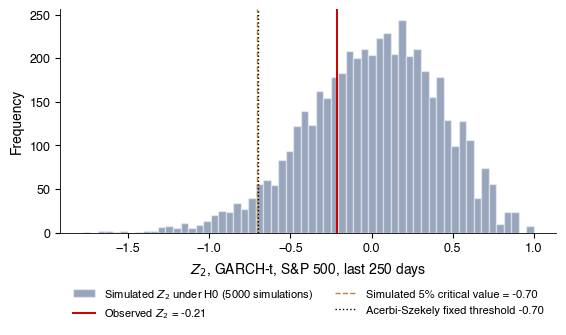

,MF_n,MF_mean,MF_t,MF_p,MF_p_normal,Z1,Z2,p2,crit5,T,Z2_last,p2_last,crit5_last,n_last
GARCH-t,192.0,0.106271,1.796752,0.0228,0.036977,-0.044570,-0.617725,0.0000,-0.152921,4959.0,-0.209918,0.2888,-0.704728,6.0
FHS,130.0,0.093171,1.213800,0.0962,0.113521,-0.040810,-0.091392,0.1536,-0.150320,4959.0,0.142024,0.6024,-0.710421,4.0
HS,156.0,0.363481,2.879161,0.0006,0.002276,-0.116912,-0.405430,0.0000,-0.153584,4959.0,0.722735,0.9754,-0.715814,2.0


In [19]:
# Solution
def b3_es_sp500():
    out = {}
    for m in ('GARCH-t', 'FHS', 'HS'):
        df = fc('sp500')[0][m]
        mf = mcneil_frey(df['L'].values, df['VaR2.5'].values, df['ES2.5'].values, df['scale'].values)
        z = z2_null('sp500', m)
        zl = z2_null('sp500', m, last=250)
        out[m] = dict(MF_n=mf['n'], MF_mean=mf['mean'], MF_t=mf['t'], MF_p=mf['p'],
                      MF_p_normal=float(stats.t.sf(mf['t'], mf['n'] - 1)),
                      Z1=z['Z1'], Z2=z['Z2'], p2=z['p'], crit5=z['crit5'], T=z['T'],
                      Z2_last=zl['Z2'], p2_last=zl['p'], crit5_last=zl['crit5'], n_last=zl['n_hit'])
        if m == 'GARCH-t':
            fig, ax = plt.subplots(figsize=(6.4, 2.9))
            ax.hist(zl['sims'], bins=60, color=MainBlue, alpha=0.45, edgecolor='white', label='Simulated $Z_2$ under H0 (5000 simulations)')
            ax.axvline(zl['Z2'], color=IDAred, lw=1.4, label=f'Observed $Z_2$ = {zl["Z2"]:.2f}')
            ax.axvline(zl['crit5'], color=Amber, ls='--', lw=1.0, label=f'Simulated 5% critical value = {zl["crit5"]:.2f}')
            ax.axvline(-0.70, color='black', ls=':', lw=1.0, label='Acerbi-Szekely fixed threshold -0.70')
            ax.set_xlabel(r'$Z_2$, GARCH-t, S&P 500, last 250 days')
            ax.set_ylabel('Frequency')
            legend_outside_bottom(ax, ncol=2, y=-0.2)
            save_fig('ch8_sem_z2_sim')
    return out


pd.DataFrame(b3_es_sp500()).T

### B4. $Z_2$ by simulation on the BET and Bitcoin [Proposed]

- Interpretation: why does the verdict change between the full sample and the last year?

In [ ]:
# Your code here


### B5. Is FHS significantly better? [Solved]

- Interpretation: when does ignoring autocorrelation overstate significance?

In [21]:
# Solution
def b5_dm_sp500():
    Lf = fz_losses('sp500')
    out = {}
    for a, b in (('GARCH-t', 'FHS'), ('HS', 'FHS'), ('GARCH-EVT', 'FHS')):
        d = Lf[a] - Lf[b]
        dm = diebold_mariano(Lf[a], Lf[b])
        naive = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
        out[f'{a}|{b}'] = dict(dbar=float(d.mean()), DM=dm['DM'], p=dm['p'], naive=float(naive),
                               lrv_ratio=float(nw_var(d.values) / d.var()))
    out['mean'] = {m: float(v) for m, v in Lf.mean().items()}
    out['T'] = len(Lf)
    out['lags'] = int(np.floor(4 * (len(Lf) / 100) ** (2 / 9)))
    return out


b5_dm_sp500()

{'GARCH-t|FHS': {'dbar': 0.038839952630652416,
  'DM': np.float64(2.653155660702952),
  'p': np.float64(0.007974308691769677),
  'naive': 2.724475179212569,
  'lrv_ratio': 1.0544846200487672},
 'HS|FHS': {'dbar': 0.4172853161596149,
  'DM': np.float64(4.697519094248522),
  'p': np.float64(2.633405731557068e-06),
  'naive': 7.179711413861121,
  'lrv_ratio': 2.33602167653801},
 'GARCH-EVT|FHS': {'dbar': 0.0028646794128979916,
  'DM': np.float64(1.2382066956350282),
  'p': np.float64(0.21563942949306003),
  'naive': 1.3073311135893915,
  'lrv_ratio': 1.1147690384891527},
 'mean': {'HS': -3.134042841441771,
  'Normal': -2.9578279082047287,
  'Student-t': -3.036176263201934,
  'GARCH-t': -3.5124882049707327,
  'FHS': -3.5513281576013855,
  'GARCH-EVT': -3.548463478188488},
 'T': 4959,
 'lags': 9}

In [22]:
# Solution, B5 sub-task 5 (optional): Giacomini-White conditional test
def b5_gw_sp500():
    """Conditional Giacomini-White test on the FZ0 differentials against FHS."""
    Lf = fz_losses('sp500')
    return {f'{a}|FHS': gw_test(Lf[a], Lf['FHS']) for a in ('GARCH-t', 'HS', 'GARCH-EVT')}


b5_gw_sp500()

{'GARCH-t|FHS': {'W': 7.592905563180893,
  'p': 0.02245026677950203,
  'unc': 2.7227125572825184,
  'p_unc': 0.006474836629907912},
 'HS|FHS': {'W': 53.37636026140564,
  'p': 2.5672646285645425e-12,
  'unc': 7.143396558186129,
  'p_unc': 9.10524491333155e-13},
 'GARCH-EVT|FHS': {'W': 7.381528930515911,
  'p': 0.024952919109342213,
  'unc': 1.307237652385337,
  'p_unc': 0.19113201154081527}}

### B6. Comparing models on Bitcoin and EUR/RON [Proposed]

- Interpretation: why is the model confidence set so large for Bitcoin?

In [ ]:
# Your code here


### B7. Conformal VaR in calm and crisis periods [Solved] — after the lecture

- Simulated i.i.d. returns are exchangeable, but their rolling-standardised scores only approximately so: near-nominal coverage is, there, an empirical finding, not a consequence of the conformal theorem.
- Interpretation: what changes between real and i.i.d. data, coverage or independence?

In [24]:
# Solution
def b7_conformal_sp500():
    out = {}
    for a in (0.05, 0.01):
        r = load_returns('sp500')
        c = conformal_var(r, a=a).loc[fc('sp500')[0]['HS'].index[0]:]
        reg = regimes(r, c.index)
        hs = c['L'] > c['VaR_split']
        # simulation: same procedure on i.i.d. Student-t returns (exchangeable returns; rolling scores only approximately)
        rng = np.random.default_rng(5)
        x = pd.Series(rng.standard_t(4, len(r)) * 0.01, index=r.index)
        ci = conformal_var(x, a=a).loc[c.index[0]:]
        regi = regimes(x, ci.index)
        hi = ci['L'] > ci['VaR_split']
        out[str(a)] = dict(T=len(c), rate=float(hs.mean()), calm=float(hs[~reg].mean()), crisis=float(hs[reg].mean()),
                           kup=kupiec(hs.values, a)['p'], iid_rate=float(hi.mean()), iid_calm=float(hi[~regi].mean()),
                           iid_crisis=float(hi[regi].mean()), n_crisis=int(reg.sum()),
                           ind=christoffersen(hs.values, a)['p_ind'], ind_iid=christoffersen(hi.values, a)['p_ind'])
    return out


pd.DataFrame(b7_conformal_sp500()).T

,T,rate,calm,crisis,kup,iid_rate,iid_calm,iid_crisis,n_crisis,ind,ind_iid
0.05,4959.0,0.053438,0.050165,0.072931,0.271685,0.047389,0.046784,0.052632,713.0,0.000032,0.965171
0.01,4959.0,0.012906,0.011540,0.021038,0.049029,0.007260,0.007197,0.007797,713.0,0.001386,0.468031


### B8. Conformal VaR on the BET and Bitcoin [Proposed]

- Interpretation: does ACI fix conditional coverage, or only the long-run average?

In [ ]:
# Your code here


### B9. Kupiec size under estimation risk [Proposed]

- Interpretation: how does the size distortion of the Kupiec test grow with $P/R$?

In [ ]:
# Your code here


## Part C — open questions and AI critique

### C1. A provisional model for a Romanian trading portfolio [Proposed]

- A RON portfolio: half in the BET index, half in euro valued at the BNR reference rate.
- Align the prices on common trading days first, then compute returns; combine regulatory and statistical evidence.

In [ ]:
# Your code here


### C2. Critique an AI answer [Proposed]

- Questions:
  - is the AI answer in the Seminar 8 slides correct?
  - does its conclusion ("the model must be withdrawn") survive once the code is fixed?
- Inputs: the prompt, the answer and its line-numbered code (slides); the test series below (401 prices from 100, daily log returns $0.01\times t_4/\sqrt2$, seed 8, with $r=-8\%$ at position 320); real data: S&P 500 daily closes from 1990.
- Tasks: find the three conceptual errors; say how you would detect each; run the answer's code and your corrected code on the test series and on the S&P 500; give the correct zone, plus factor and multiplier for 7 exceptions (A5).

In [ ]:
# Input for C2: the test price series
def c2_fixture(n=400, day=320, shock=-0.08, seed=8):
    """C2 test price series: 400 prices from 100, daily log returns 1% x standardised Student-t4, seed 8,
    with a return of -8% on day 320."""
    rng = np.random.default_rng(seed)
    r = 0.01 * rng.standard_t(4, n) / np.sqrt(2)
    r[day] = shock
    P = 100 * np.exp(np.r_[0, np.cumsum(r)])
    return P


P_test = c2_fixture()
print(len(P_test), round(P_test[0], 2))

In [ ]:
# Work here: the answer's code and your corrected code


### C3. Backtesting ES with ES forecasts only [Proposed]

- C3 is solved in **R** with the authors' package `esback` (function `esr_backtest`), not in this Python notebook; the statement and the assessment rubric are in the Seminar 8 slides.
- Inputs: the ES 2.5% forecasts of the six models in the four markets (24 series), with the paper's sign convention $r_t=-L_t$, $\hat e_t=-\widehat{\mathrm{ES}}_t$; the cell below exports them to CSV files for R.

In [ ]:
# Input for C3: export returns and ES forecasts for R
for mk in ('sp500', 'bet', 'btc', 'eurron'):
    F, _ = fc(mk)
    out = pd.DataFrame({m: -F[m]['ES2.5'] for m in F})
    out.insert(0, 'r', -F['GARCH-t']['L'])
    out.to_csv(f'c3_{mk}.csv')
    print(mk, out.shape)